Only to ensure Onyxia GPUs to work.

In [1]:
# Onyxia GPU compatible torch version
import sys
!{sys.executable} -m pip install torch==2.11.0 torchaudio torchvision \
    --index-url https://download.pytorch.org/whl/cu126 \
    --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 98.0 MB/s  0:00:07:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 95.5 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 103.0 MB/s  0:00:0200:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 105.5 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 102.6 MB/s  0:00:0300:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 205.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 105.2 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 168.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 105.3 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 107.6 MB/s

# Topic modeling

Here is our full implementation of a BERTopic unsupervised model applied to biathlon. 
*Please note that if you try to run the code, the topics described in this notebook might change of index.*

Creation of the corpus dataframe.
*If you want to analyse another sport, please change the path accordingly.*

In [5]:
import pandas as pd
import os

data_path = "PESSD/biath/"

df = pd.DataFrame()
for file in os.listdir(data_path) : 
    temp = pd.read_csv(data_path+file)
    df = pd.concat([df,temp])


Small preporcessing : removing non relevant texts, nouns, stopwords and splitting interventions into sentences.

In [6]:
import re
import string

# Removing music and noise (only technical commentary)
df = df[(df["main_g"]=="female")|(df["main_g"]=="male")]

# text to sentences
df["text"] = df["text"].apply(lambda x : x.split(". "))
df = df.explode("text")

# Removes all words with capitals
df["text"] = df["text"].apply(lambda x : re.sub(r"\s*[A-Z]\w*\s*", " ", x).strip())

# Removes empty texts
df = df[df["text"].str.strip() != ""]

# Remove punctuation
df ["text"] = df["text"].apply(lambda x : x.translate(str.maketrans('', '', string.punctuation.replace("'", ""))))

Adding metadata of the files (gender of the athletes).

In [10]:
df["ID"] = df["audio_file"].str.replace("_wav.wav","")
df = df.merge(pd.read_csv("metadata.csv"), on="ID")
df

,start,stop,text,main_speaker,main_g,audio_file,ID,g_ath
0,0.00,24.00,un italien que l'on a vu en gros plan on vou...,SPEAKER_02,male,BH_wav.wav,BH,H
1,0.00,24.00,90 biathlètes aujourd'hui et vous le voyez un ...,SPEAKER_02,male,BH_wav.wav,BH,H
2,0.00,24.00,sprint extrêmement important et parce que déj...,SPEAKER_02,male,BH_wav.wav,BH,H
3,24.00,45.32,tout à fait c'est une course qui est très impo...,SPEAKER_00,female,BH_wav.wav,BH,H
4,24.00,45.32,c'est sûr qu'il faut essayer de grappiller des...,SPEAKER_00,female,BH_wav.wav,BH,H
...,...,...,...,...,...,...,...,...
8765,6223.82,6232.82,'est super,SPEAKER_05,male,BI_wav.wav,BI,H
8766,6223.82,6232.82,,SPEAKER_05,male,BI_wav.wav,BI,H
8767,6232.82,6254.90,beaucoup,SPEAKER_02,male,BI_wav.wav,BI,H
8768,6232.82,6254.90,ces jouissons loin d'être terminés pour,SPEAKER_02,male,BI_wav.wav,BI,H


Unserpervised topic model based on the corpus.
*If using CPU, please remove the "device" argument in* `SentenceTransformer`.

In [11]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan

# Stopwords list
STOPWORDS = [x.strip() for x in open('stopwords.txt').readlines()]

# Docs 
docs = df["text"]

# Vectorizer for topic representation
vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    ngram_range=(1,2),
    min_df=2
    #token_pattern=r"\b(?!\w*[A-Z])\w+\b" # theoreticaly removes words with capital letters once embeddings are done
)

# To control for number and size of clusters
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,      # high for larger topics
    min_samples=10,
    cluster_selection_epsilon=0.1,
    cluster_selection_method='leaf',
    prediction_data=True
)

# Load CamemBERT embedding model
embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base", device="cuda") # remove device if CPU

# Influence choice of themes
seed =  [
["émotion","larme","ému","joie","tristesse"],
["famille","parents","ami", "personnel", "conjoint"]]

# Build BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    language="french",
    calculate_probabilities=True,
    verbose=True,
    seed_topic_list=None    
)

# Fit the model
topics, probs = topic_model.fit_transform(docs)

# Show discovered topics
# print(topic_model.get_topic_info())

# Visualize topic hierarchy
topic_model.visualize_hierarchy()

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2806.11it/s]
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-29 16:47:48,471 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 275/275 [00:14<00:00, 18.83it/s]
2026-04-29 16:48:03,144 - BERTopic - Embedding - Completed ✓
2026-04-29 16:48:03,145 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 16:49:22,230 - BERTopic - Dimensionality - Comp

One can see that around 39% of the corpus is not attributed to a topic (3412/8770). The attributed texts are rather uniformously distributed across topics.
The names of the topic also indicates one potential empty topic (6).

In [12]:
topic_model.get_topic_info()[["Topic", "Name","Count"]]

,Topic,Name,Count
0,-1,-1_secondes_individuel_tir_tête,2990
1,0,0_surprise_fort_énorme_grand,389
2,1,1_10_position_tête_10 10,286
3,2,2_tir_tir tir_tireur_tirs,281
4,3,3_secondes_10 secondes_avance_secondes avance,279
5,4,4_équipe_groupe_filles_athlètes,269
6,5,5_attention_aïe_oui_présents,262
7,6,6_skis_ski_temps ski_rapide,250
8,7,7_montée_bosse_glisse_descente,195
9,8,8____,189


Adding topics and topic probabilites to the corpus dataframe.

In [13]:
df["topic"] = topics
df["topic_prob"] = probs.max(axis=1)

One can now check the content of each topic by file (ie discipline or moment of the competition).

In [14]:
# Sentences of topic i and by sport
for _, j in df[df["topic"]==4][["text","ID"]].iterrows():
    print(j["ID"],"_", j["text"])

BH _ 90 biathlètes aujourd'hui et vous le voyez un public très nombreux
BH _ avant que les grands noms ne s'élancent un petit détour par on revient très vite ici pour vivre en intégralité ce sprint messieurs
BH _ tout cas voilà pour les pronostics du grand frère d'eux
BH _ pense qu'aujourd'hui l' peut faire un joli coup avec des athlètes  ou même  
BH _  on va j'espère aller un peu sur le départ des têtes d'affiches
BH _ sur la piste à l'instant  le qui a pris les commandes
BH _ Ça glisse bien pour l'équipe d'  ils sont souvent très performants au niveau matériel
BH _ allemands qui sont dans le dur simultanément et c'est   qui pour l'instant sont en train de mener les débats
BH _ sont partis peutêtre pour réaliser un doublé
BH _ se retrouvera autour de la minute à la bagarre pour la poursuite
BH _ est super longue cette arrivée on voit les athlètes ils sont marqués
BH _ que vous avez les protagonistes de cette course c'est micro ouvert pour vous
BH _ bien là il est déjà à 2 titres et l

One can also check the main words shaping a topic. Here related to the speed of the athletes.

In [15]:
topic_model.get_topic(4)

[('équipe', np.float64(0.08457745256574221)),
 ('groupe', np.float64(0.04906655252066048)),
 ('filles', np.float64(0.04719447144231479)),
 ('athlètes', np.float64(0.04321205268353437)),
 ('garçons', np.float64(0.031989877261626824)),
 ('athlète', np.float64(0.028557673171170108)),
 ('nations', np.float64(0.028527927998847378)),
 ('favorites', np.float64(0.027717352629046645)),
 ('poursuite', np.float64(0.026379734134828733)),
 ('coach', np.float64(0.023455342744872744))]

Topic 8 is indeed empty and can be removed of the corpus.

In [ ]:
# Sentences of topic i and by sport
for _, j in df[df["topic"]==8][["text","ID"]].iterrows():
    print(j["ID"],"_", j["text"])

df = df[df["topic"]!=8]

BH _  
BH _ 
BH _ 
BH _ à  '
BH _ 
BH _ 
BH _ 
BH _ 
BIR2 _ 
BIR2 _ 
BIR2 _  
BIR2 _ 
BIR2 _ 
BIR2 _ 
BIR2 _      
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _ 
BMH _    
BMH _ 
BMH _ 
BMH _  
BMH _ 
BMH _ 
BMH _ 
BMH _   
BMH _ 
BMH _   
BIR1 _ 
BIR1 _  
BIR1 _ 
BIR1 _ 
BIR1 _ 
BHR _ nouveau encore
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ 
BHR _ à quand même
BHR _  
BHR _  
BSF _ 
BSF _ 
BSF _ 
BSF _ 
BSF _ 
BSF _ 
BSF _ 
BSF _  
BSF _ 
BSF _  
BSF _ 
BSF _ 
BSF _ 
BSF _ 
BAP _ 
BAP _ 
BAP _ 
BAP _ 
BAP _  
BAP _ 
BAP _ 
BAP _ 
BAP _ 
BAP _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _ 
BAH _  
BAH _ 
BAH _ 
BAH _ 
BFR _ 
BFR _  
BFR _ 
BFR _  
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BFR _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _  
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _ 
BIF _  
BIF _ 
BIF _   
BIF _ 


To summerise the information, the share of commentary on women(*F*), men (*H*) and both (*M*) are computed by topic.

In [19]:
# Only classified docs
clf = df[df["topic"]!=-1]
adf = pd.DataFrame()
for i in range(len(clf["topic"].unique())) :
    tmp = df[df["topic"]==i]
    tmp = tmp["g_ath"].value_counts(normalize=True)
    tmp = pd.DataFrame([{
    "topic": f"topic_{i}",
    "M": tmp.get("M", 0),
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
    adf = pd.concat([adf,tmp])

# All topics
tmp = clf["g_ath"].value_counts(normalize=True)
tmp = pd.DataFrame([{
    "topic": "all_topics",
    "M": tmp.get("M", 0),
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
adf = pd.concat([adf,tmp])

for col in ["M", "F", "H"]:
    ref = tmp[col]
    adf[f"{col}_diff"] = adf[col] - ref
    adf[f"{col}_diff"] = adf[f"{col}_diff"].apply(
        lambda x: f"{x*100:+.1f}%" if pd.notna(x) else ""
    )

adf


,topic,M,F,H,M_diff,F_diff,H_diff
0,topic_0,0.084833,0.316195,0.598972,-1.8%,-5.5%,+7.3%
0,topic_1,0.097902,0.388112,0.513986,-0.5%,+1.7%,-1.2%
0,topic_2,0.056940,0.373665,0.569395,-4.6%,+0.3%,+4.3%
0,topic_3,0.103943,0.405018,0.491039,+0.1%,+3.4%,-3.5%
0,topic_4,0.126394,0.323420,0.550186,+2.4%,-4.8%,+2.4%
0,topic_5,0.103053,0.393130,0.503817,+0.0%,+2.2%,-2.2%
0,topic_6,0.000000,0.000000,0.000000,-10.3%,-37.1%,-52.6%
0,topic_7,0.189744,0.312821,0.497436,+8.7%,-5.8%,-2.9%
0,topic_8,0.063492,0.386243,0.550265,-3.9%,+1.5%,+2.4%
0,topic_9,0.069892,0.317204,0.612903,-3.3%,-5.4%,+8.7%


One can follow the same logic but with the gender of the commentator.

In [20]:
# Only classified docs
df["main_g"] = df["main_g"].map({"male" : "H", "female" : "F"})
clf = df[df["topic"]!=-1]
cdf = pd.DataFrame()

for i in range(len(clf["topic"].unique())) :
    tmp = df[df["topic"]==i]
    tmp = tmp["main_g"].value_counts(normalize=True)
    tmp = pd.DataFrame([{
    "topic": f"topic_{i}",
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
    cdf = pd.concat([cdf,tmp])

# All topics
tmp = clf["main_g"].value_counts(normalize=True)
tmp = pd.DataFrame([{
    "topic": "all_topics",
    "F": tmp.get("F", 0),
    "H": tmp.get("H", 0)
}])
cdf = pd.concat([cdf,tmp])

for col in ["F", "H"]:
    ref = tmp[col]
    cdf[f"{col}_diff"] = cdf[col] - ref
    cdf[f"{col}_diff"] = cdf[f"{col}_diff"].apply(
        lambda x: f"{x*100:+.1f}%" if pd.notna(x) else ""
    )

cdf


,topic,F,H,F_diff,H_diff
0,topic_0,0.259640,0.740360,+6.5%,-6.5%
0,topic_1,0.108392,0.891608,-8.6%,+8.6%
0,topic_2,0.341637,0.658363,+14.7%,-14.7%
0,topic_3,0.093190,0.906810,-10.1%,+10.1%
0,topic_4,0.167286,0.832714,-2.7%,+2.7%
0,topic_5,0.171756,0.828244,-2.2%,+2.2%
0,topic_6,0.000000,0.000000,-19.4%,-80.6%
0,topic_7,0.246154,0.753846,+5.2%,-5.2%
0,topic_8,0.206349,0.793651,+1.2%,-1.2%
0,topic_9,0.102151,0.897849,-9.2%,+9.2%


plot

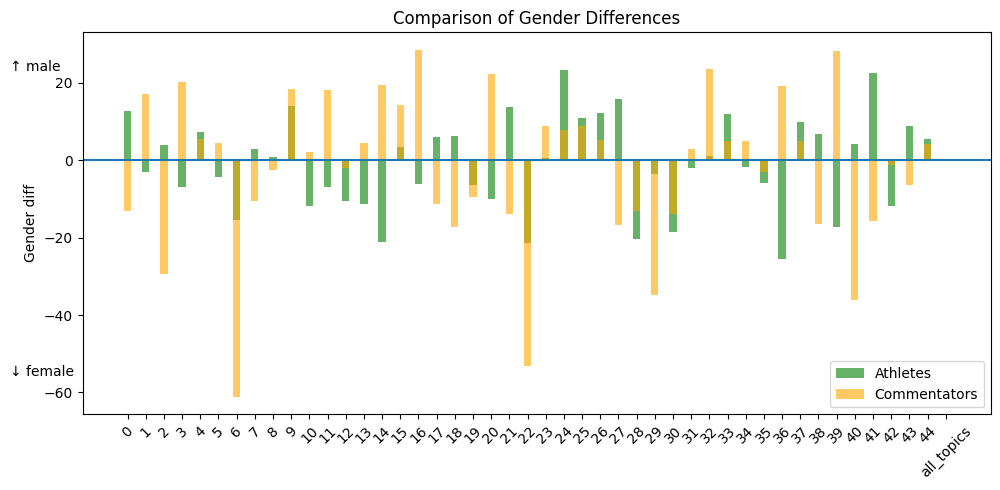

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def prepare_df(df):
    df = df.copy()
    for col in ['F_diff', 'H_diff']:
        df[col] = df[col].str.replace('%', '').astype(float)
    # single metric: male vs female dominance
    df['gender_diff'] = df['H_diff'] - df['F_diff']
    return df

adf_p = prepare_df(adf)
cdf_p = prepare_df(cdf)

x = np.arange(len(adf_p['topic']))

plt.figure(figsize=(10,5))

# Plot both with slight offset + transparency
plt.bar(x, adf_p['gender_diff'], width=0.4, alpha=0.6, label='Athletes', color='green')
plt.bar(x, cdf_p['gender_diff'], width=0.4, alpha=0.6, label='Commentators', color='orange')

plt.axhline(0)
plt.xticks(x, adf_p['topic'].str.replace("topic_",""), rotation=45)
plt.ylabel("Gender diff")
plt.title("Comparison of Gender Differences")
plt.annotate("↑ male", xy=(-0.08, 0.9), xycoords='axes fraction', fontsize=10)
plt.annotate("↓ female", xy=(-0.08, 0.1), xycoords='axes fraction', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

Topic 12, 22, 27 and 36 show the biggest gap with the gender shares across all topics.
12 seems to be linked to the relay disciplines, 22 to the compliments on the performance, 27 on the efforts and intensity of the athletes and 36 on taking the lead.

In [32]:
print(topic_model.get_topic(12))
print(topic_model.get_topic(22))
print(topic_model.get_topic(27))
print(topic_model.get_topic(36))

[('relais', np.float64(0.17554919592197524)), ('relayeur', np.float64(0.07280344281807817)), ('mixte', np.float64(0.06504694335990772)), ('relais relais', np.float64(0.04973246080475016)), ('histoire', np.float64(0.04740459846003804)), ('relais mixte', np.float64(0.042385284153419744)), ('zone mixte', np.float64(0.041443717337291804)), ('micro', np.float64(0.03778640158801846)), ('zone', np.float64(0.03578323695473153)), ('relayeurs', np.float64(0.03230348097160908))]
[('course', np.float64(0.25431195674014945)), ('course course', np.float64(0.11121267394453493)), ('belle course', np.float64(0.09395073485748226)), ('sacrée course', np.float64(0.0662802682638889)), ('courses', np.float64(0.06489073297215889)), ('courir', np.float64(0.06127102403606209)), ('couru', np.float64(0.05871920928592641)), ('sacrée', np.float64(0.056567447757796534)), ('mastarte', np.float64(0.05580488079126336)), ('belle', np.float64(0.0546948819663203))]
[('vraiment', np.float64(0.019206207217509028)), ('faut'

Looking more in depth into the topics, it appears that the 27th, though quite noisy, shows the thema of resilience ("effort continu", "se remobiliser", "ne pas craquer"...), which is found to be especially feminine in the literature as in our data.

Topic 28, about emotions, is also more feminine though in a lesser magnitude.

In [38]:
for _, j in df[df["topic"]==27][["text","ID"]].iterrows():
    print(j["ID"],"_", j["text"])

BMF _ sont parties prud'hommes je trouve que là on sent le relâchement sur les skis elles en mettent mais voilà ça reste un effort qui est maîtrisé là pour les françaises
BMF _ selon les configurations du tir si il y en a une ou deux qui partent seules en tête c'est là où il va falloir faire un gros temps de ski pour creuser mais là pour l'instant ça sert à rien de s'exciter
BMF _ là ça neige pas mal et ça temporise quand même cette bosse on voit que l'effort ne sont pas à 100 là les filles parce que derrière  elle reprend du temps
BI _ ouais voilà c'est une grosse pénalité après aujourd'hui c'est quand même une piste pour les gros skieurs parce que parce qu'on vous le détaillera un peu plus tard mais il y a vraiment un effort continu à fournir tout au long des quatre kilomètres qu'ils auront à effectuer cinq fois  vous aurez le 38 de   donc leader du classement général de la du  leader du petit globe de l'individuel grand favori même s'il a encore en face de lui du beau monde
BI _ vou

To see if the topics are consistent, we run the model without 20% of the corpus.
*GPU here is mandatory.*

In [39]:
# Main words of current model themes

reference = set()
for topic_id in topic_model.get_topics():
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
    reference.add(tuple(sorted(words)))

10 runs at 80%. Stability is measured with the Jaccard Index between reference model topics and 80% runs topics. If the index is higher than 0.2 7 times or more, the topic is considered stable.

In [41]:
from sklearn.utils import resample
from collections import Counter

# List of words for each topic for each model
all_topics_words = []

# Number of runs
nb_iter = 10

for i in range(nb_iter):

    # First, resample 80% of docs
    sample = resample(docs, n_samples=int(len(docs) * 0.8), random_state=i)

    # Same model specification
    model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    language="french",
    calculate_probabilities=True,
    verbose=True,
    seed_topic_list=seed    
)
    model.fit(sample)
    
    # Top 10 words per topic
    top_words = set()
    for topic_id in model.get_topics():
        if topic_id == -1:
            continue
        words = [w for w, _ in model.get_topic(topic_id)[:10]]
        top_words.add(tuple(sorted(words)))
    
    all_topics_words.append(top_words)


# Jaccard similarity index
def jaccard(t1, t2):
    s1, s2 = set(t1), set(t2)
    return len(s1 & s2) / len(s1 | s2)

# Topic stability
"""
Measures similarity between reference topic and topics found in other runs.

Thresholds for stability are determined by Jaccard index (threshold) and number of occurences (min_run)
"""
def is_stable(topic, all_runs, threshold=0.2, min_runs=7):
    count = 0
    for run_topics in all_runs:
        if any(jaccard(topic, t) >= threshold for t in run_topics):
            count += 1
    return count >= min_runs


stable_topics = [t for t in reference if is_stable(t, all_topics_words)]

print(f"Stable topics (≥7 runs out of 10) : {len(stable_topics)}")
for t in stable_topics:
    print(t)


2026-04-28 19:44:32,097 - BERTopic - Embedding - Transforming documents to embeddings.
Batches:   0%|          | 0/220 [00:00<?, ?it/s]

Batches: 100%|██████████| 220/220 [00:08<00:00, 24.81it/s]
2026-04-28 19:44:41,034 - BERTopic - Embedding - Completed ✓
2026-04-28 19:44:41,036 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 48.55it/s]
2026-04-28 19:44:41,195 - BERTopic - Guided - Completed ✓
2026-04-28 19:44:41,196 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-28 19:45:23,074 - BERTopic - Dimensionality - Completed ✓
2026-04-28 19:45:23,076 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-28 19:45:24,216 - BERTopic - Cluster - Completed ✓
2026-04-28 19:45:24,226 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-28 19:45:24,391 - BERTopic - Representation - Completed ✓
2026-04-28 19:45:24,678 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 220/220 [00:08<00:00, 25.16it/s]
2026-04-28 19:45:33,485 - BERTopic - Embeddin

Stable topics (≥7 runs out of 10) : 18
('10', '10 10', '3e', 'classement', 'classement général', 'général', 'place', 'position', 'ressortir', 'tête')
('belle', 'belle course', 'courir', 'course', 'course course', 'courses', 'couru', 'mastarte', 'sacrée', 'sacrée course')
('champion', 'champion olympique', 'championne', 'championne olympique', 'médaille', 'olympique', 'olympique titre', 'olympiques', 'titre', 'titre olympique')
('', '', '', '', '', '', '', '', '', '')
('petit temps', 'relance', 'remet', 'remettre', 'reprend', 'reprendre', 'repris', 'repris temps', 'revenir', 'temps')
('droit erreur', 'déjà faute', 'erreur', 'erreurs', 'faute', 'faute fautes', 'fautes', 'fautes fautes', 'parti', 'parti faute')
('boss', 'loin', 'loin loin', 'rentrer', 'rentré', 'ressort', 'ressortir', 'sortie', 'sortir', 'train rentrer')
('15', '15 15', '18', '18 20', '19', '19 20', '20', '20 19', '20 20', 'aller chercher')
('côté', 'français', 'norvège', 'norvégien', 'norvégienne', 'norvégiens', 'suédois